<a href="https://colab.research.google.com/github/mayajdias/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maya Dias

**Date:** 09/02/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [34]:
# Phase 1 Solution to Q1 Part 1

# import pandas and numpy
import pandas as pd
import numpy as np

# read data
df = pd.read_csv('airbnb_hw.csv')
display(df.head())

#look at types
print("Initial DataFrame types:")
print(df.dtypes)

# price reads as an object. Using unique to see where this might occur
print("Unique values in Price variable:")

# discovered that price is most likely an object because values > 999 use a comma. Must convert this to integer.
df['Price'] = df['Price'].str.replace(",", "")
has_and = df["Price"].astype(str).str.contains(",", regex=False).any()
print("Do any values contain a comma?:", has_and)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Initial DataFrame types:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object
Unique values in Price variable:
Do any values contain a comma?: False


Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missing values after cleaning:
 0 



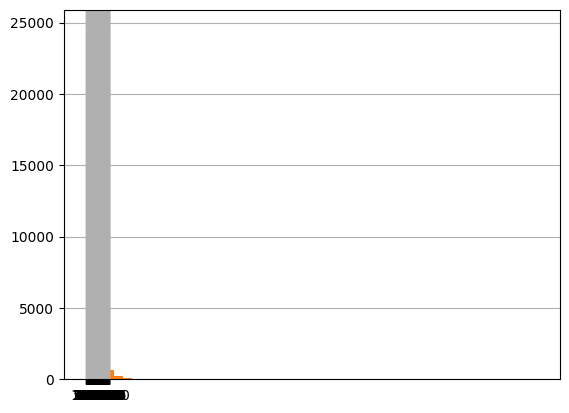

In [35]:
# Phase 1 Solution to Q1 Part 1 continued

# coerce missing values to NaN
var = 'Price'
print('Before coercion:\n', df[var].describe(), '\n')
df[var].hist(bins=50)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price_nan'] = df['Price'].isnull()

print('After coercion:\n', df['Price'].describe(), '\n')
df['Price'].hist(bins=50)

#calculate number of missing values
print('Total missing values after cleaning:\n', sum(df['Price_nan']), '\n')

In [33]:
#Phase 1 Solution to Q1 Part 2
df= pd.read_csv('mn_police_use_of_force.csv')

var = 'subject_injury'

print(df[var].unique(), '\n')
print(df[var].value_counts(dropna=False), '\n')

df['subject_injury_missing'] = df['subject_injury'].isnull()

df['subject_injury_clean'] = df['subject_injury'].fillna('Missing')

print('Number missing:', df['subject_injury_missing'].sum())
print('Proportion missing:', df['subject_injury_missing'].mean())


injury_force_table = pd.crosstab(
    df['subject_injury_clean'],
    df['force_type']
)

print(injury_force_table)


missing_by_force = pd.crosstab(
    df['force_type'],
    df['subject_injury_clean']
)

missing_by_force['Missing proportion'] = (
    missing_by_force['Missing'] /
    missing_by_force.sum(axis=1)
)

missing_by_force.sort_values(
    'Missing proportion',
    ascending=False
)

#The missing injury data appear to be related to the type of force used. Overall, about 76.2% of subject_injury values are missing, but the missing rate varies substantially by force_type. Injury status is missing for 100% of Less Lethal and Maximal Restraint Technique cases and about 89.2% of Chemical Irritant cases. In contrast, only about 26.0% of Gun Point Display cases and 40.3% of Police K9 Bite cases are missing. This is concerning because the probability that injury information is missing appears to depend on the type of force, meaning the missing data are not evenly distributed across observations.


[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Number missing: 9848
Proportion missing: 0.7619342359767892
force_type            Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_clean                                                    
Missing                   2          7051               1421        0   
No                        0          1093                131        2   
Yes                       2          1286                 41        0   

force_type            Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_clean                                                      
Missing                              27                 74           87   
No                                   33                 34            0   
Yes                                  44                 40            0   

force_type            Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury_clean   

subject_injury_clean,Missing,No,Yes,Missing proportion
force_type,,,,
Less Lethal,87,0,0,1.000000
Maximal Restraint Technique,170,0,0,1.000000
Chemical Irritant,1421,131,41,0.892028
Taser,985,150,172,0.753634
Bodily Force,7051,1093,1286,0.747720
Baton,2,0,2,0.500000
Improvised Weapon,74,34,40,0.500000
Police K9 Bite,31,2,44,0.402597
Gun Point Display,27,33,44,0.259615


df3.shape:
(7117, 23) 

df3.dtypes:
Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object') 

Shape after dropping empty columns:
(7117, 

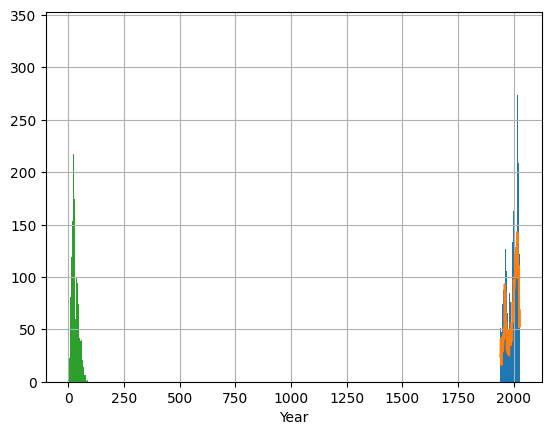

In [41]:
#Phase 1 Q2
import pandas as pd
import numpy as np

%pip install xlrd

# Open Excel File
df3 = pd.read_excel('GSAF5.xls')

# Investigate the file
print("df3.shape:")
print(df3.shape, '\n')

print("df3.dtypes:")
print(df3.dtypes, '\n')

df3.head()




# Look at the column names
print(df3.columns, '\n')

# Drop columns where every value is missing
df3 = df3.dropna(axis=1, how='all')

# Check the shape after dropping empty columns
print("Shape after dropping empty columns:")
print(df3.shape, '\n')

print(df3.columns)


var = 'Year'

# Look at the variable before cleaning
print('Before coercion:\n', df3[var].describe(), '\n')

# Convert Year to numeric
# Any values that cannot be converted become NaN
df3[var] = pd.to_numeric(df3[var], errors='coerce')

# Create a variable showing which years are missing
df3['Year_nan'] = df3[var].isnull()

# Look at Year after cleaning
print('After coercion:\n', df3[var].describe(), '\n')

print('Total missings:\n', sum(df3['Year_nan']), '\n')

print('Minimum year:', df3[var].min())
print('Maximum year:', df3[var].max())


# Keep only shark attacks from 1940 onward
df_recent = df3[df3['Year'] >= 1940]

print(df_recent.shape)

# Look at the distribution of attacks over time
df_recent['Year'].hist(bins=50)


# Count the number of attacks in each year
attacks_by_year = df_recent['Year'].value_counts().sort_index()

print(attacks_by_year)

# Plot the number of attacks by year
attacks_by_year.plot()


#Clean Age
var = 'Age'

# Look at possible values before cleaning
print(df3[var].unique(), '\n')

print('Before coercion:\n', df3[var].describe(), '\n')

# Convert Age to numeric
# Text values that cannot be interpreted as numbers become NaN
df3[var] = pd.to_numeric(df3[var], errors='coerce')

# Keep track of missing ages
df3['Age_nan'] = df3[var].isnull()

print('After coercion:\n', df3[var].describe(), '\n')

print('Total missings:\n', sum(df3['Age_nan']), '\n')

# Make a histogram of victim ages
df3[var].hist(bins=50)


#Find Male Proportion

var = 'Sex'

# Investigate the variable
print(df3[var].unique(), '\n')

print(df3[var].value_counts(dropna=False), '\n')


# Remove extra spaces and make capitalization consistent
df3['Sex_clean'] = df3['Sex'].str.strip().str.upper()

# Look at the cleaned values
print(df3['Sex_clean'].value_counts(dropna=False), '\n')

# Keep observations coded M or F
df_sex = df3[
    (df3['Sex_clean'] == 'M') |
    (df3['Sex_clean'] == 'F')
]

# Calculate the proportion that are male
proportion_male = sum(df_sex['Sex_clean'] == 'M') / len(df_sex)

print('Proportion male:', proportion_male)

print('Percent male:', proportion_male * 100)

var = 'Type'

# Look at the original categories
print(df3[var].unique(), '\n')

print(df3[var].value_counts(dropna=False), '\n')

# Start by calling everything Unknown
df3['Type_clean'] = 'Unknown'

# Keep clearly Provoked attacks as Provoked
df3.loc[df3['Type'] == 'Provoked', 'Type_clean'] = 'Provoked'

# Keep clearly Unprovoked attacks as Unprovoked
df3.loc[df3['Type'] == 'Unprovoked', 'Type_clean'] = 'Unprovoked'

# Check that we now have only three categories
print(df3['Type_clean'].unique(), '\n')

print(df3['Type_clean'].value_counts(), '\n')

# Calculate the proportion of attacks that are Unprovoked
proportion_unprovoked = sum(
    df3['Type_clean'] == 'Unprovoked'
) / len(df3)

print('Proportion unprovoked:', proportion_unprovoked)

print('Percent unprovoked:', proportion_unprovoked * 100)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]